In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nltk.download('stopwords')
nltk.download('punkt')
df = pd.read_csv('spam.csv', encoding='latin-1')
print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!



Class Distribution:
label
0    0.865937
1    0.134063
Name: proportion, dtype: float64


/tmp/ipython-input-3482241350.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['label'].map({'ham': 0, 'spam': 1})


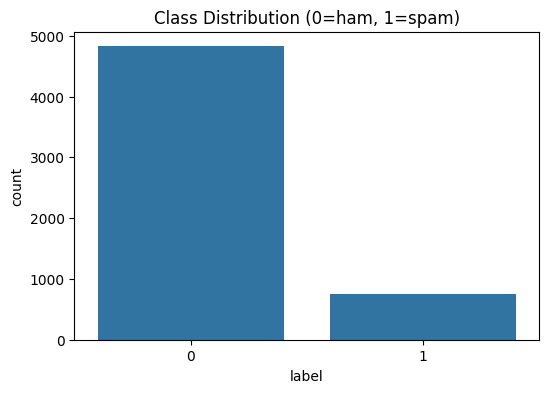

In [6]:
if not df.empty:
    df = df.iloc[:, :2]
    df.columns = ['label', 'text']

    df['label'] = df['label'].map({'ham': 0, 'spam': 1})
    print("\nClass Distribution:")
    print(df['label'].value_counts(normalize=True))

    plt.figure(figsize=(6, 4))
    sns.countplot(x='label', data=df)
    plt.title('Class Distribution (0=ham, 1=spam)')
    plt.show()

In [8]:
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens_no_punct = [t for t in tokens if t not in string.punctuation]
    tokens_no_stop = [t for t in tokens_no_punct if t not in stop_words]
    return ' '.join(tokens_no_stop)

df['clean_text'] = df['text'].apply(preprocess_text)
print(df[['text', 'clean_text']].head())

tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"TF-IDF Training data shape: {X_train.shape}")
print(f"TF-IDF Testing data shape: {X_test.shape}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                                text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                          clean_text  
0  go jurong point crazy .. available bugis n gre...  
1                    ok lar ... joking wif u oni ...  
2  free entry 2 wkly comp win fa cup final tkts 2...  
3        u dun say early hor ... u c already say ...  
4         nah n't think goes usf lives around though  
TF-IDF Training data shape: (4457, 3000)
TF-IDF Testing data shape: (1115, 3000)


/tmp/ipython-input-3617545920.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_text'] = df['text'].apply(preprocess_text)


Train Accuracy: 0.8836
Test Accuracy: 0.8951



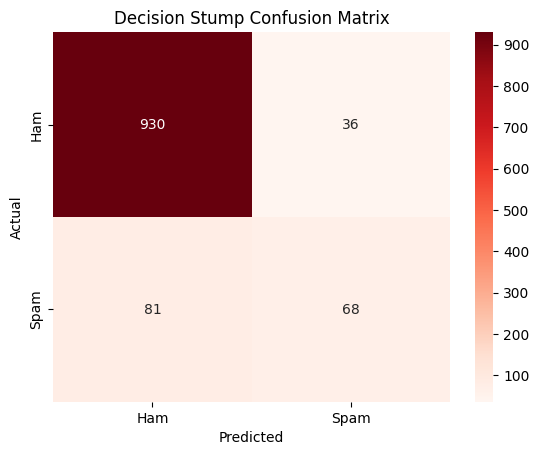

In [9]:
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)

y_pred_train_stump = stump.predict(X_train)
train_acc_stump = accuracy_score(y_train, y_pred_train_stump)
print(f"Train Accuracy: {train_acc_stump:.4f}")

y_pred_test_stump = stump.predict(X_test)
test_acc_stump = accuracy_score(y_test, y_pred_test_stump)
print(f"Test Accuracy: {test_acc_stump:.4f}\n")
cm_stump = confusion_matrix(y_test, y_pred_test_stump)
sns.heatmap(cm_stump, annot=True, fmt='d', cmap='Reds',xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Stump Confusion Matrix')
plt.show()

In [10]:
y_train_m1 = y_train.map({0: -1, 1: 1}).values

N = len(y_train)
T = 15

weights = np.full(N, 1/N)

stumps = []
alphas = []
weighted_errors = []
iteration_numbers = list(range(1, T + 1))
X_train_dense = X_train.toarray()
y_train_arr = y_train.values

for t in iteration_numbers:
    stump = DecisionTreeClassifier(max_depth=1, random_state=42)
    stump.fit(X_train, y_train, sample_weight=weights)

    y_pred_stump = stump.predict(X_train)
    y_pred_stump_m1 = np.array([1 if p == 1 else -1 for p in y_pred_stump])

    misclassified_mask = (y_pred_stump != y_train_arr)
    misclassified_indices = np.where(misclassified_mask)[0]

    error = np.sum(weights[misclassified_mask])
    error = max(error, 1e-9)
    weighted_errors.append(error)

    alpha = 0.5 * np.log((1 - error) / error)
    alphas.append(alpha)
    print(f"Misclassified sample indices (first 20): {misclassified_indices[:20]}")
    print(f"Weights of misclassified (first 20): {weights[misclassified_indices[:20]]}")
    print(f"Weighted Error (Epsilon): {error:.6f}")
    print(f"Alpha: {alpha:.6f}")

    weights = weights * np.exp(-alpha * y_train_m1 * y_pred_stump_m1)
    weights = weights / np.sum(weights)
    stumps.append(stump)


Misclassified sample indices (first 20): [ 14  42  49  50  59  62  86  93  96 100 103 115 121 140 142 157 162 194
 195 196]
Weights of misclassified (first 20): [0.00022437 0.00022437 0.00022437 0.00022437 0.00022437 0.00022437
 0.00022437 0.00022437 0.00022437 0.00022437 0.00022437 0.00022437
 0.00022437 0.00022437 0.00022437 0.00022437 0.00022437 0.00022437
 0.00022437 0.00022437]
Weighted Error (Epsilon): 0.116446
Alpha: 1.013262
Misclassified sample indices (first 20): [  9  15  22  31  39  49  59  66  76  88  93 114 121 123 159 162 166 174
 194 203]
Weights of misclassified (first 20): [0.00012697 0.00012697 0.00012697 0.00012697 0.00012697 0.00096339
 0.00096339 0.00012697 0.00012697 0.00012697 0.00096339 0.00012697
 0.00096339 0.00012697 0.00012697 0.00096339 0.00012697 0.00012697
 0.00096339 0.00096339]
Weighted Error (Epsilon): 0.247721
Alpha: 0.555402
Misclassified sample indices (first 20): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 16 17 18 19 20 21]
Weights of misclassifie

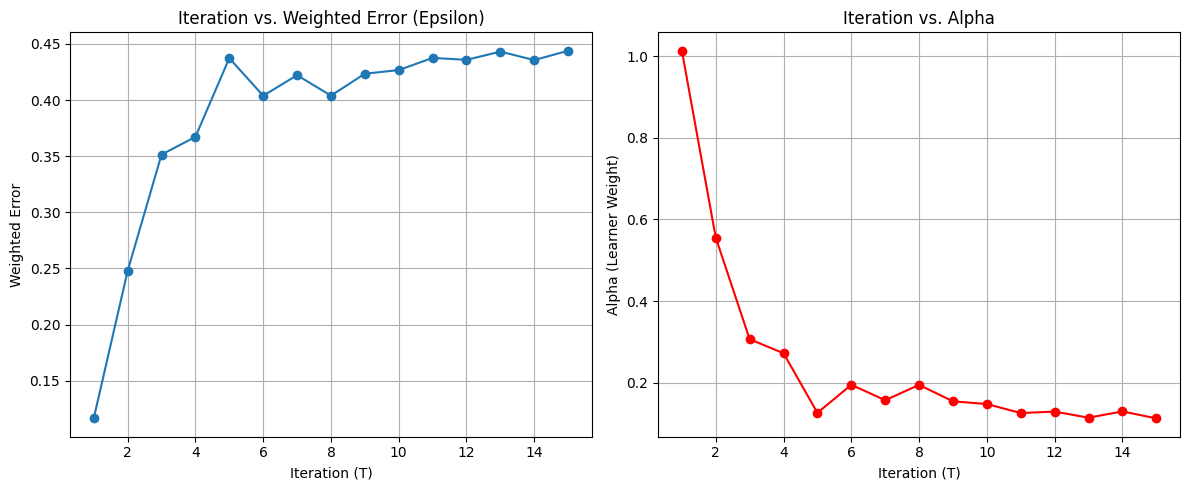

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(iteration_numbers, weighted_errors, marker='o')
plt.title('Iteration vs. Weighted Error (Epsilon)')
plt.xlabel('Iteration (T)')
plt.ylabel('Weighted Error')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(iteration_numbers, alphas, marker='o', color='r')
plt.title('Iteration vs. Alpha')
plt.xlabel('Iteration (T)')
plt.ylabel('Alpha (Learner Weight)')
plt.grid(True)

plt.tight_layout()
plt.show()

Train Accuracy: 0.9172
Test Accuracy: 0.9256



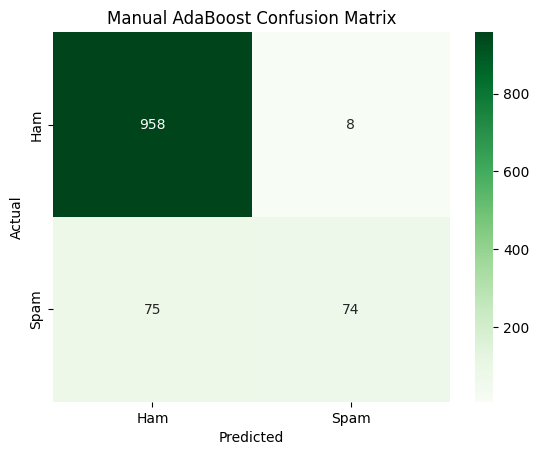

In [12]:
def manual_adaboost_predict(X):
    stump_preds = np.array([stump.predict(X) for stump in stumps])
    stump_preds_m1 = np.where(stump_preds == 1, 1, -1)

    final_scores = np.dot(alphas, stump_preds_m1)
    final_preds = np.sign(final_scores)
    return np.where(final_preds == 1, 1, 0)

y_pred_train_manual = manual_adaboost_predict(X_train)
train_acc_manual = accuracy_score(y_train, y_pred_train_manual)
print(f"Train Accuracy: {train_acc_manual:.4f}")

y_pred_test_manual = manual_adaboost_predict(X_test)
test_acc_manual = accuracy_score(y_test, y_pred_test_manual)
print(f"Test Accuracy: {test_acc_manual:.4f}\n")

cm_manual = confusion_matrix(y_test, y_pred_test_manual)
sns.heatmap(cm_manual, annot=True, fmt='d', cmap='Greens',xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Manual AdaBoost Confusion Matrix')
plt.show()

Train Accuracy: 0.9147
Test Accuracy: 0.9184



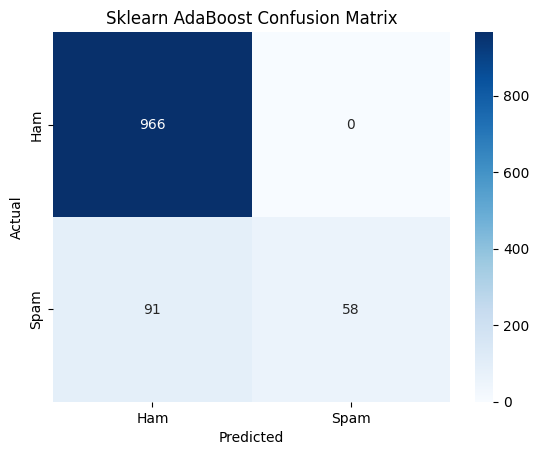

In [14]:
stump_sklearn = DecisionTreeClassifier(max_depth=1)

sklearn_ada = AdaBoostClassifier(estimator=stump_sklearn,n_estimators=100,learning_rate=0.6,random_state=42)

sklearn_ada.fit(X_train, y_train)

y_pred_train_sklearn = sklearn_ada.predict(X_train)
train_acc_sklearn = accuracy_score(y_train, y_pred_train_sklearn)
print(f"Train Accuracy: {train_acc_sklearn:.4f}")

y_pred_test_sklearn = sklearn_ada.predict(X_test)
test_acc_sklearn = accuracy_score(y_test, y_pred_test_sklearn)
print(f"Test Accuracy: {test_acc_sklearn:.4f}\n")

cm_sklearn = confusion_matrix(y_test, y_pred_test_sklearn)
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues',xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Sklearn AdaBoost Confusion Matrix')
plt.show()

In [16]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

heart = fetch_openml(name="heart-disease", version=1, as_frame=True)

df = heart.frame
X = df.drop("target", axis=1)
y = df["target"]
feature_names = heart.feature_names
print(df.head())
print(df.shape)

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  3.0     145.0  233.0  1.0      0.0    150.0    0.0      2.3   
1  37.0  1.0  2.0     130.0  250.0  0.0      1.0    187.0    0.0      3.5   
2  41.0  0.0  1.0     130.0  204.0  0.0      0.0    172.0    0.0      1.4   
3  56.0  1.0  1.0     120.0  236.0  0.0      1.0    178.0    0.0      0.8   
4  57.0  0.0  0.0     120.0  354.0  0.0      1.0    163.0    1.0      0.6   

   slope   ca  thal  target  
0    0.0  0.0   1.0     1.0  
1    0.0  0.0   2.0     1.0  
2    2.0  0.0   2.0     1.0  
3    2.0  0.0   2.0     1.0  
4    2.0  0.0   2.0     1.0  
(303, 14)
Training data shape: (242, 13)
Testing data shape: (61, 13)


Training Accuracy: 0.7397
Test Accuracy: 0.8361



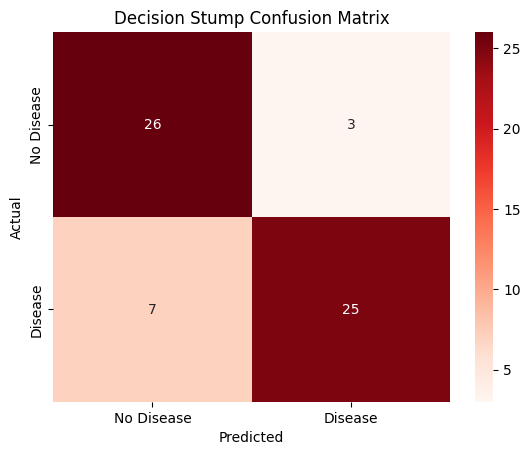

              precision    recall  f1-score   support

  No Disease       0.79      0.90      0.84        29
     Disease       0.89      0.78      0.83        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [17]:
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train_scaled, y_train)

y_pred_train_stump = stump.predict(X_train_scaled)
train_acc_stump = accuracy_score(y_train, y_pred_train_stump)

y_pred_test_stump = stump.predict(X_test_scaled)
test_acc_stump = accuracy_score(y_test, y_pred_test_stump)

print(f"Training Accuracy: {train_acc_stump:.4f}")
print(f"Test Accuracy: {test_acc_stump:.4f}\n")

cm_stump = confusion_matrix(y_test, y_pred_test_stump)
sns.heatmap(cm_stump, annot=True, fmt='d', cmap='Reds',xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Stump Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_test_stump, target_names=['No Disease', 'Disease']))

In [19]:
n_estimators_list = [5, 10, 25, 50, 100]
learning_rate_list = [0.1, 0.5, 1.0]

results = []
base_learner = DecisionTreeClassifier(max_depth=1, random_state=42)

for lr in learning_rate_list:
    for n_est in n_estimators_list:
        ada = AdaBoostClassifier(estimator=base_learner,n_estimators=n_est, learning_rate=lr, random_state=42)
        ada.fit(X_train_scaled, y_train)

        y_pred_test_ada = ada.predict(X_test_scaled)
        test_acc_ada = accuracy_score(y_test, y_pred_test_ada)

        results.append({'learning_rate': lr,'n_estimators': n_est,'test_accuracy': test_acc_ada})

results_df = pd.DataFrame(results)
print(results_df.head())

   learning_rate  n_estimators  test_accuracy
0            0.1             5       0.901639
1            0.1            10       0.885246
2            0.1            25       0.885246
3            0.1            50       0.868852
4            0.1           100       0.852459


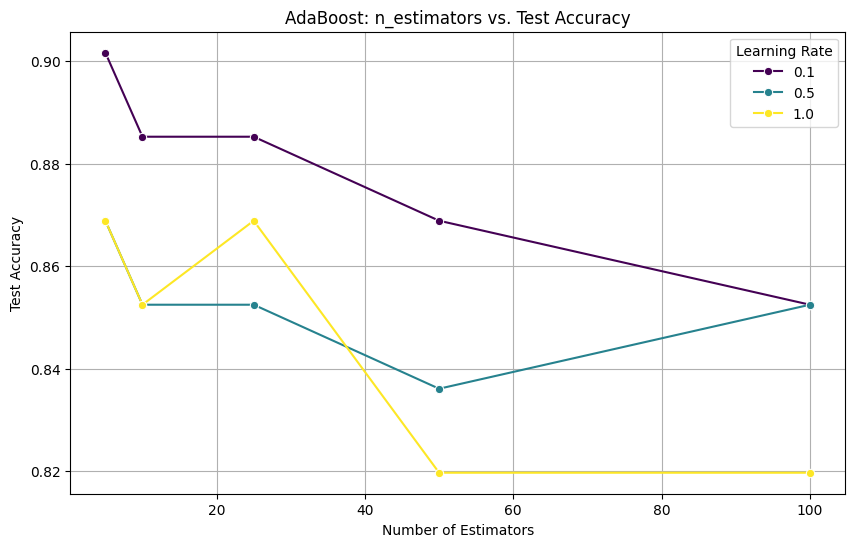

In [20]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x='n_estimators', y='test_accuracy', hue='learning_rate', marker='o', palette='viridis')
plt.title('AdaBoost: n_estimators vs. Test Accuracy')
plt.xlabel('Number of Estimators')
plt.ylabel('Test Accuracy')
plt.legend(title='Learning Rate')
plt.grid(True)
plt.show()

In [21]:
best_config = results_df.loc[results_df['test_accuracy'].idxmax()]
print(f"Best configuration found:\n{best_config}")
print(f"\nHighest Test Accuracy: {best_config['test_accuracy']:.4f}")

best_lr = best_config['learning_rate']
best_n_est = int(best_config['n_estimators'])

Best configuration found:
learning_rate    0.100000
n_estimators     5.000000
test_accuracy    0.901639
Name: 0, dtype: float64

Highest Test Accuracy: 0.9016


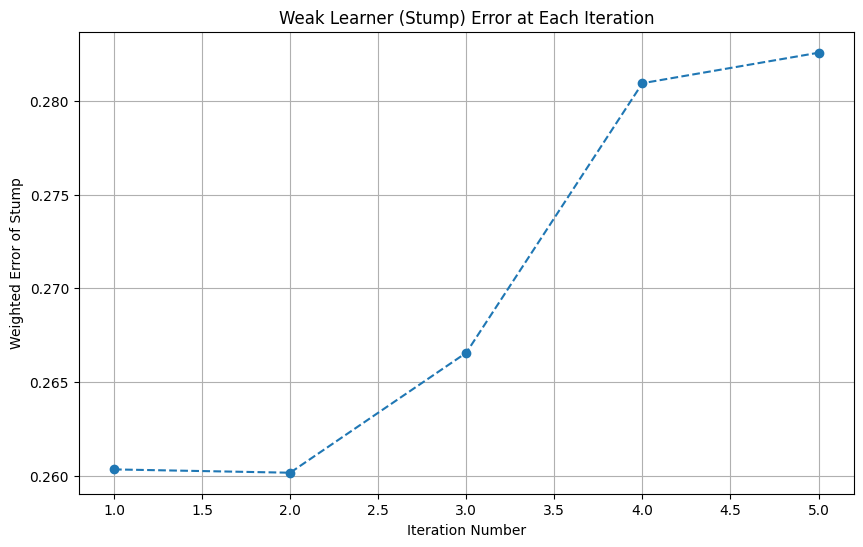

In [23]:
best_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=best_n_est, learning_rate=best_lr, random_state=42)
best_model.fit(X_train_scaled, y_train)

learner_errors = best_model.estimator_errors_
plt.figure(figsize=(10, 6))
plt.plot(range(1, best_n_est + 1), learner_errors, marker='o', linestyle='--')
plt.title('Weak Learner (Stump) Error at Each Iteration')
plt.xlabel('Iteration Number')
plt.ylabel('Weighted Error of Stump')
plt.grid(True)
plt.show()

Length of importances: 13
Length of feature_names: 13
Top 5 most important features:
ca      0.399137
cp      0.397335
thal    0.203528
age     0.000000
sex     0.000000
dtype: float64



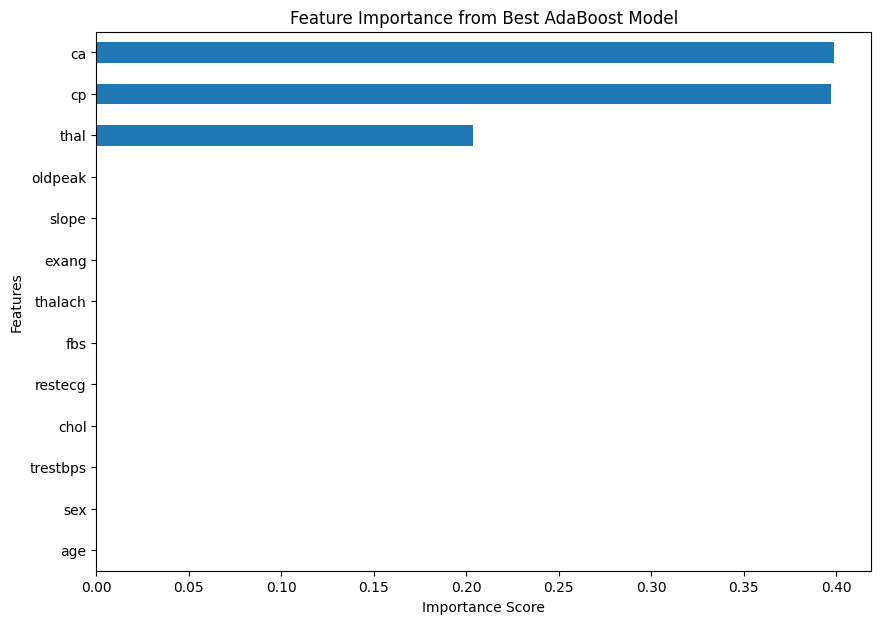

In [27]:
feature_names = heart.feature_names[:13]

importances = best_model.feature_importances_

print(f"Length of importances: {len(importances)}")
print(f"Length of feature_names: {len(feature_names)}")

feat_imp = pd.Series(importances, index=feature_names)

top_5_features = feat_imp.nlargest(5)
print(f"Top 5 most important features:\n{top_5_features}\n")

plt.figure(figsize=(10, 7))
feat_imp.sort_values().plot(kind='barh')
plt.title('Feature Importance from Best AdaBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [28]:
import kagglehub
path = kagglehub.dataset_download("nusratuljannatmary/wisdmmar")

print("Path to dataset files:", path)

100%|██████████| 11.0M/11.0M [00:00<00:00, 144MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nusratuljannatmary/wisdmmar/versions/1


In [29]:
column_names = ['user_id', 'activity', 'timestamp', 'x', 'y', 'z']
df = pd.read_csv('WISDM_ar_v1.1_raw.txt', header=None, names=column_names, on_bad_lines='skip')
print(df.head())

   user_id activity     timestamp         x          y             z
0       33  Jogging  4.910596e+13 -0.694638  12.680544   0.50395286;
1       33  Jogging  4.910606e+13  5.012288  11.264028   0.95342433;
2       33  Jogging  4.910611e+13  4.903325  10.882658  -0.08172209;
3       33  Jogging  4.910622e+13 -0.612916  18.496431    3.0237172;
4       33  Jogging  4.910633e+13 -1.184970  12.108489     7.205164;


In [30]:
df['z'] = df['z'].astype(str).str.replace(';', '', regex=False)
df['z'] = pd.to_numeric(df['z'], errors='coerce')
df.dropna(inplace=True)

vigorous_activities = ['Jogging', 'Upstairs']
static_activities = ['Walking', 'Sitting', 'Standing', 'Downstairs']

df = df[df['activity'].isin(vigorous_activities + static_activities)].copy()
df['label'] = df['activity'].apply(lambda x: 1 if x in vigorous_activities else 0)

X = df[['x', 'y', 'z']].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Data Shape:", X.shape)
print("Class Distribution (1=Vigorous, 0=Static):")
print(pd.Series(y).value_counts())
print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Data Shape: (41686, 3)
Class Distribution (1=Vigorous, 0=Static):
1    22165
0    19521
Name: count, dtype: int64

Training set shape: (29180, 3)
Test set shape: (12506, 3)


Baseline Stump Train Accuracy: 0.6308
Baseline Stump Test Accuracy:  0.6330


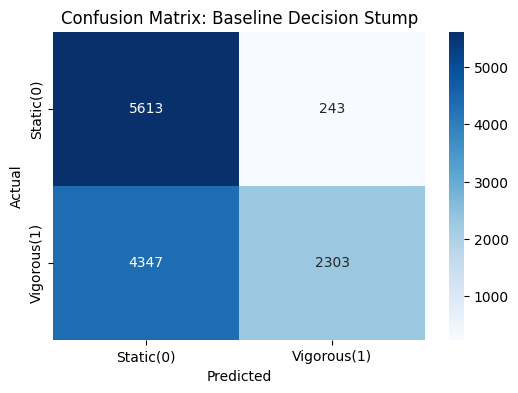

In [31]:
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)

y_pred_train = stump.predict(X_train)
y_pred_test = stump.predict(X_test)

print(f"Baseline Stump Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Baseline Stump Test Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")

cm_stump = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_stump, annot=True, fmt='d', cmap='Blues', xticklabels=['Static(0)', 'Vigorous(1)'], yticklabels=['Static(0)', 'Vigorous(1)'])
plt.title("Confusion Matrix: Baseline Decision Stump")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Iter  | Alpha      | Error      | Misclassified Count
------------------------------------------------------------
1     | 0.2679     | 0.3692     | 10772
2     | 0.2407     | 0.3819     | 13665
3     | 0.2281     | 0.3879     | 12222
4     | 0.1635     | 0.4190     | 13665
5     | 0.1779     | 0.4120     | 11550
6     | 0.1461     | 0.4275     | 13665
7     | 0.1500     | 0.4256     | 13468
8     | 0.1267     | 0.4370     | 13665
9     | 0.1351     | 0.4329     | 11379
10    | 0.1127     | 0.4439     | 13665
11    | 0.1075     | 0.4465     | 13641
12    | 0.0957     | 0.4523     | 13665
13    | 0.0843     | 0.4579     | 13693
14    | 0.0767     | 0.4617     | 13665
15    | 0.1088     | 0.4458     | 12794
16    | 0.0906     | 0.4548     | 13665
17    | 0.0990     | 0.4506     | 11579
18    | 0.0855     | 0.4574     | 13665
19    | 0.0650     | 0.4675     | 13848
20    | 0.0971     | 0.4516     | 10592


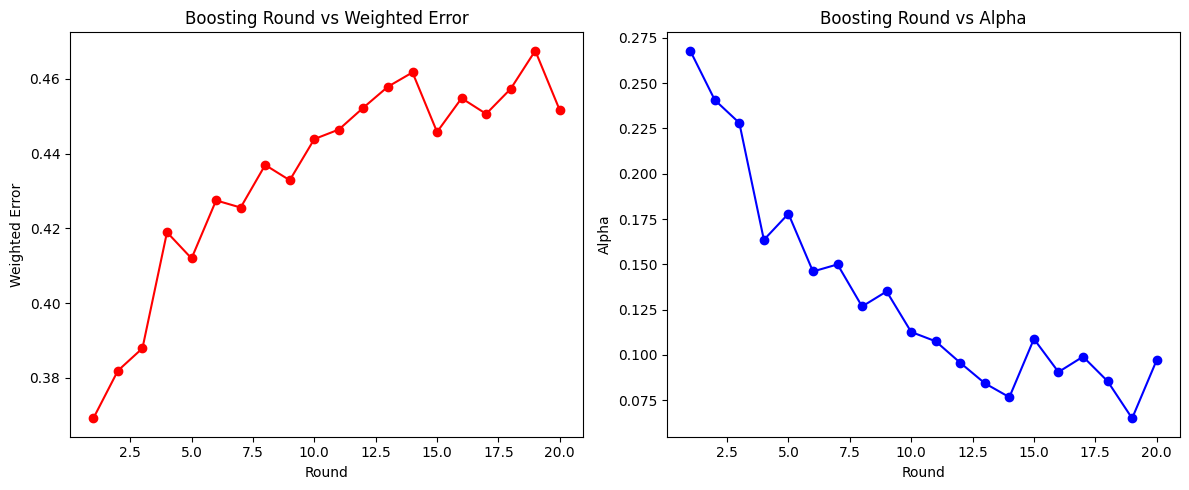

Train Accuracy: 0.7478
Test Accuracy:  0.7531


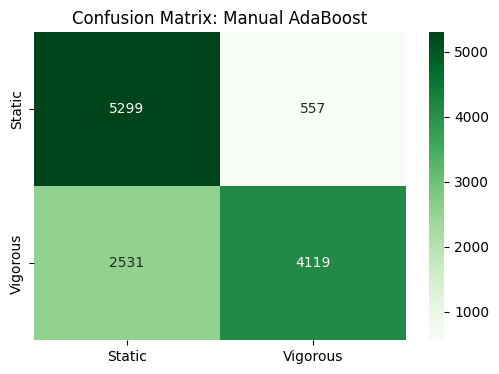

In [32]:
n_train = X_train.shape[0]
n_test = X_test.shape[0]
T = 20

sample_weights = np.full(n_train, 1 / n_train)
clfs = []
alphas = []
errors_history = []
alpha_history = []

y_train_ada = np.where(y_train == 0, -1, 1)
y_test_ada = np.where(y_test == 0, -1, 1)

print(f"{'Iter':<5} | {'Alpha':<10} | {'Error':<10} | {'Misclassified Count'}")
print("-" * 60)

for t in range(T):
    clf = DecisionTreeClassifier(max_depth=1, random_state=42)
    clf.fit(X_train, y_train, sample_weight=sample_weights)

    pred_01 = clf.predict(X_train)
    pred_ada = np.where(pred_01 == 0, -1, 1)

    misclassified_mask = (pred_ada != y_train_ada)

    error = np.dot(sample_weights, misclassified_mask)

    error = np.clip(error, 1e-10, 1 - 1e-10)

    alpha = 0.5 * np.log((1 - error) / error)

    clfs.append(clf)
    alphas.append(alpha)
    errors_history.append(error)
    alpha_history.append(alpha)

    misclassified_indices = np.where(misclassified_mask)[0]
    misclassified_weights = sample_weights[misclassified_indices]

    print(f"{t+1:<5} | {alpha:.4f}     | {error:.4f}     | {len(misclassified_indices)}")
    if len(misclassified_weights) > 0:
        pass

    sample_weights *= np.exp(-alpha * y_train_ada * pred_ada)
    sample_weights /= np.sum(sample_weights)

final_scores_train = np.zeros(n_train)
for clf, alpha in zip(clfs, alphas):
    p = clf.predict(X_train)
    p_mapped = np.where(p == 0, -1, 1)
    final_scores_train += alpha * p_mapped
final_pred_train = np.where(final_scores_train >= 0, 1, 0)

final_scores_test = np.zeros(n_test)
for clf, alpha in zip(clfs, alphas):
    p = clf.predict(X_test)
    p_mapped = np.where(p == 0, -1, 1)
    final_scores_test += alpha * p_mapped
final_pred_test = np.where(final_scores_test >= 0, 1, 0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, T+1), errors_history, marker='o', color='red')
plt.title('Boosting Round vs Weighted Error')
plt.xlabel('Round')
plt.ylabel('Weighted Error')

plt.subplot(1, 2, 2)
plt.plot(range(1, T+1), alpha_history, marker='o', color='blue')
plt.title('Boosting Round vs Alpha')
plt.xlabel('Round')
plt.ylabel('Alpha')

plt.tight_layout()
plt.show()

print(f"Train Accuracy: {accuracy_score(y_train, final_pred_train):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, final_pred_test):.4f}")

cm_manual = confusion_matrix(y_test, final_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_manual, annot=True, fmt='d', cmap='Greens', xticklabels=['Static', 'Vigorous'], yticklabels=['Static', 'Vigorous'])
plt.title("Confusion Matrix: Manual AdaBoost")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Train Accuracy: 0.7560
Test Accuracy:  0.7612


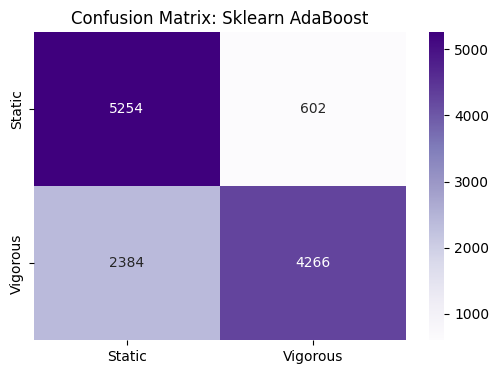

In [33]:
ada_sk = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, learning_rate=1.0, algorithm='SAMME', random_state=42)

ada_sk.fit(X_train, y_train)

y_pred_sk_train = ada_sk.predict(X_train)
y_pred_sk_test = ada_sk.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, y_pred_sk_train):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred_sk_test):.4f}")

cm_sk = confusion_matrix(y_test, y_pred_sk_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Purples', xticklabels=['Static', 'Vigorous'], yticklabels=['Static', 'Vigorous'])
plt.title("Confusion Matrix: Sklearn AdaBoost")
plt.show()